Load all preprocessed arrays

In [1]:
import joblib
import numpy as np

# Load all preprocessed data in one line
data = joblib.load('fyp_preprocessed_data.pkl')

# 80/20 split
X_train_80_lr_bal   = data['X_train_80_lr']
X_train_80_tree_bal = data['X_train_80_tree']
X_test_80_lr        = data['X_test_80_lr']
X_test_80_tree      = data['X_test_80_tree']
y_train_80_bal      = data['y_train_80']
y_test_80           = data['y_test_80']

# 70/30 split
X_train_70_lr_bal   = data['X_train_70_lr']
X_train_70_tree_bal = data['X_train_70_tree']
X_test_70_lr        = data['X_test_70_lr']
X_test_70_tree      = data['X_test_70_tree']
y_train_70_bal      = data['y_train_70']
y_test_70           = data['y_test_70']

# Preprocessors (for later — dashboard)
preprocessor_lr      = data['preprocessor_lr']
preprocessor_tree    = data['preprocessor_tree']
preprocessor_lr_70   = data['preprocessor_lr_70']
preprocessor_tree_70 = data['preprocessor_tree_70']

print("All data loaded successfully.")
print(f"  X_train_80_tree_bal : {X_train_80_tree_bal.shape}")
print(f"  X_train_70_tree_bal : {X_train_70_tree_bal.shape}")
print(f"  X_train_80_lr_bal   : {X_train_80_lr_bal.shape}")
print(f"  X_train_70_lr_bal   : {X_train_70_lr_bal.shape}")

All data loaded successfully.
  X_train_80_tree_bal : (286353, 12)
  X_train_70_tree_bal : (250560, 12)
  X_train_80_lr_bal   : (286353, 85)
  X_train_70_lr_bal   : (250560, 85)


1.Random Forest

In [2]:
# Evaluation helper function (define once, reuse for all models)
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score)

def evaluate_model(model, X_test, y_test, model_name, split_label):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)

    acc     = accuracy_score(y_test, y_pred)
    f1_mac  = f1_score(y_test, y_pred, average='macro')
    f1_wt   = f1_score(y_test, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
    cm      = confusion_matrix(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"  {model_name} — {split_label}")
    print(f"{'='*60}")
    print(f"  Accuracy         : {acc:.4f}")
    print(f"  F1 (macro)       : {f1_mac:.4f}")
    print(f"  F1 (weighted)    : {f1_wt:.4f}")
    print(f"  ROC-AUC (macro)  : {roc_auc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred,
          target_names=['Low Risk', 'Medium Risk', 'High Risk']))

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Low', 'Medium', 'High'],
                yticklabels=['Low', 'Medium', 'High'])
    plt.title(f'Confusion Matrix — {model_name} ({split_label})', fontsize=12)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    fname = f"cm_{model_name.replace(' ','_')}_{split_label.replace('/','_')}.png"
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  Confusion matrix saved → {fname}")

    return {
        'Model'       : model_name,
        'Split'       : split_label,
        'Accuracy'    : round(acc,    4),
        'F1_macro'    : round(f1_mac, 4),
        'F1_weighted' : round(f1_wt,  4),
        'ROC_AUC'     : round(roc_auc,4)
    }

# Shared results list — every model appends here
results = []
print("Evaluation function defined. Results list initialised.")

Evaluation function defined. Results list initialised.


In [3]:
# ── Train Random Forest — 80/20 ──────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier

rf_80 = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest (80/20)...")
rf_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Random Forest (80/20)...
Done.


In [4]:
# Train Random Forest — 70/30 
rf_70 = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = 42,
    n_jobs       = -1
)

print("Training Random Forest (70/30)...")
rf_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Random Forest (70/30)...
Done.



  Random Forest — 80/20
  Accuracy         : 0.7076
  F1 (macro)       : 0.4250
  F1 (weighted)    : 0.6917
  ROC-AUC (macro)  : 0.6697

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     23864
 Medium Risk       0.42      0.34      0.38      7728
   High Risk       0.11      0.06      0.07      1144

    accuracy                           0.71     32736
   macro avg       0.44      0.42      0.43     32736
weighted avg       0.68      0.71      0.69     32736



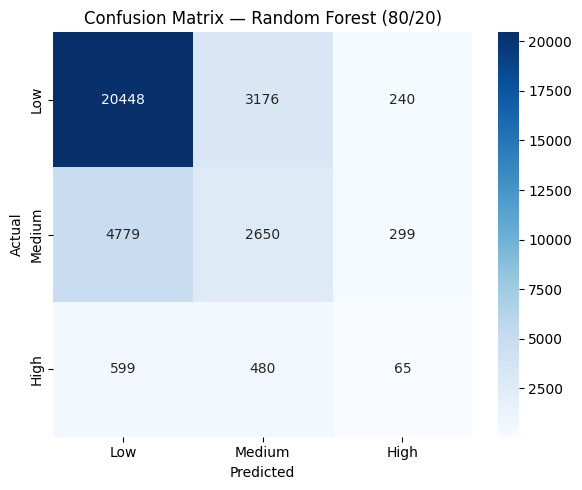

  Confusion matrix saved → cm_Random_Forest_80_20.png

  Random Forest — 70/30
  Accuracy         : 0.7043
  F1 (macro)       : 0.4201
  F1 (weighted)    : 0.6878
  ROC-AUC (macro)  : 0.6682

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     35795
 Medium Risk       0.41      0.33      0.37     11592
   High Risk       0.11      0.05      0.07      1716

    accuracy                           0.70     49103
   macro avg       0.44      0.41      0.42     49103
weighted avg       0.68      0.70      0.69     49103



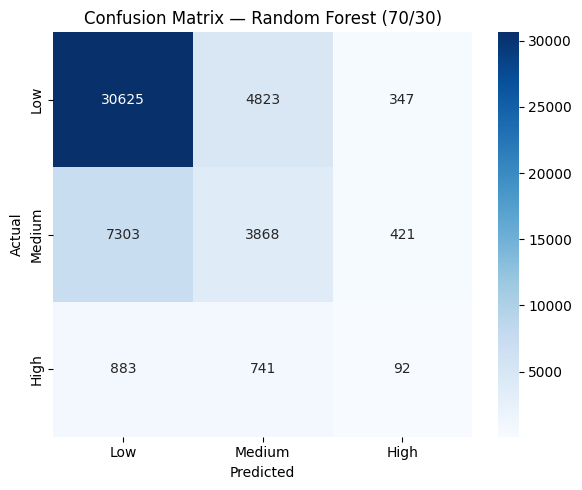

  Confusion matrix saved → cm_Random_Forest_70_30.png


In [5]:
#  Evaluate Random Forest — both splits
res_rf_80 = evaluate_model(rf_80, X_test_80_tree, y_test_80,
                            'Random Forest', '80/20')
res_rf_70 = evaluate_model(rf_70, X_test_70_tree, y_test_70,
                            'Random Forest', '70/30')

results.append(res_rf_80)
results.append(res_rf_70)

In [6]:
# ── Hyperparameter Tuning — Random Forest (80/20) ────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators'      : [100, 200, 300],
    'max_depth'         : [None, 10, 20, 30],
    'min_samples_split' : [2, 5, 10],
    'min_samples_leaf'  : [1, 2, 4],
    'max_features'      : ['sqrt', 'log2'],
    'class_weight'      : ['balanced']
}

rf_search_80 = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 15,          # 15 random combinations
    cv                  = 3,           # 3-fold cross-validation
    scoring             = 'f1_macro',  # fair across imbalanced classes
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning Random Forest (80/20)... this may take several minutes.\n")
rf_search_80.fit(X_train_80_tree_bal, y_train_80_bal)

rf_tuned_80 = rf_search_80.best_estimator_

print(f"\nBest parameters (80/20):")
for p, v in rf_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {rf_search_80.best_score_:.4f}")

Tuning Random Forest (80/20)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  n_estimators         : 100
  min_samples_split    : 5
  min_samples_leaf     : 1
  max_features         : log2
  max_depth            : None
  class_weight         : balanced

Best CV F1-macro : 0.8214


In [7]:
# Hyperparameter Tuning — Random Forest (70/30)
rf_search_70 = RandomizedSearchCV(
    estimator           = RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions = param_dist,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning Random Forest (70/30)... this may take several minutes.\n")
rf_search_70.fit(X_train_70_tree_bal, y_train_70_bal)

rf_tuned_70 = rf_search_70.best_estimator_

print(f"\nBest parameters (70/30):")
for p, v in rf_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {rf_search_70.best_score_:.4f}")

Tuning Random Forest (70/30)... this may take several minutes.

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  n_estimators         : 100
  min_samples_split    : 5
  min_samples_leaf     : 1
  max_features         : log2
  max_depth            : None
  class_weight         : balanced

Best CV F1-macro : 0.8246



  Random Forest Tuned — 80/20
  Accuracy         : 0.7189
  F1 (macro)       : 0.4290
  F1 (weighted)    : 0.6997
  ROC-AUC (macro)  : 0.6851

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.87      0.83     23864
 Medium Risk       0.44      0.34      0.39      7728
   High Risk       0.11      0.05      0.07      1144

    accuracy                           0.72     32736
   macro avg       0.45      0.42      0.43     32736
weighted avg       0.69      0.72      0.70     32736



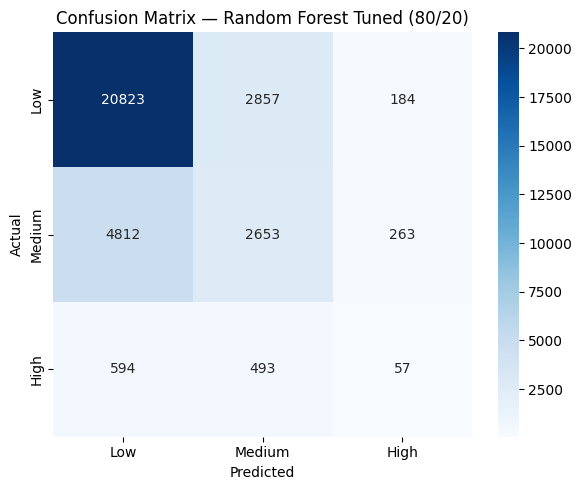

  Confusion matrix saved → cm_Random_Forest_Tuned_80_20.png

  Random Forest Tuned — 70/30
  Accuracy         : 0.7164
  F1 (macro)       : 0.4245
  F1 (weighted)    : 0.6959
  ROC-AUC (macro)  : 0.6813

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.87      0.83     35795
 Medium Risk       0.43      0.33      0.38     11592
   High Risk       0.12      0.05      0.07      1716

    accuracy                           0.72     49103
   macro avg       0.45      0.42      0.42     49103
weighted avg       0.68      0.72      0.70     49103



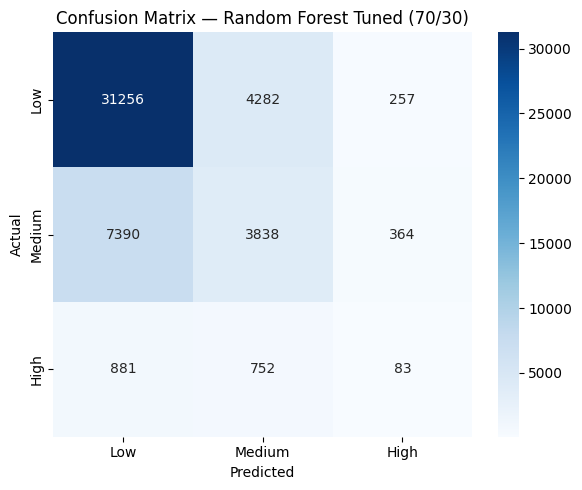

  Confusion matrix saved → cm_Random_Forest_Tuned_70_30.png


In [8]:
# Evaluate tuned Random Forest — both splits
res_rf_tuned_80 = evaluate_model(rf_tuned_80, X_test_80_tree, y_test_80,
                                  'Random Forest Tuned', '80/20')
res_rf_tuned_70 = evaluate_model(rf_tuned_70, X_test_70_tree, y_test_70,
                                  'Random Forest Tuned', '70/30')

results.append(res_rf_tuned_80)
results.append(res_rf_tuned_70)

In [9]:
# Random Forest Models — Comparison Summary
import pandas as pd

rf_comparison = pd.DataFrame([
    res_rf_80,        # baseline 80/20
    res_rf_70,        # baseline 70/30
    res_rf_tuned_80,  # tuned 80/20
    res_rf_tuned_70   # tuned 70/30
])

print("Random Forest — Baseline vs Tuned Comparison")
print("=" * 70)
print(rf_comparison.to_string(index=False))

Random Forest — Baseline vs Tuned Comparison
              Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Random Forest 80/20    0.7076    0.4250       0.6917   0.6697
      Random Forest 70/30    0.7043    0.4201       0.6878   0.6682
Random Forest Tuned 80/20    0.7189    0.4290       0.6997   0.6851
Random Forest Tuned 70/30    0.7164    0.4245       0.6959   0.6813


2.xgboost

In [6]:
# Train XGBoost — 80/20
from xgboost import XGBClassifier

xgb_80 = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.3,
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)

print("Training XGBoost (80/20)...")
xgb_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training XGBoost (80/20)...
Done.


In [7]:
# Train XGBoost — 70/30
xgb_70 = XGBClassifier(
    n_estimators     = 100,
    max_depth        = 6,
    learning_rate    = 0.3,
    objective        = 'multi:softprob',
    num_class        = 3,
    eval_metric      = 'mlogloss',
    random_state     = 42,
    n_jobs           = -1
)

print("Training XGBoost (70/30)...")
xgb_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training XGBoost (70/30)...
Done.



  XGBoost — 80/20
  Accuracy         : 0.7191
  F1 (macro)       : 0.3034
  F1 (weighted)    : 0.6267
  ROC-AUC (macro)  : 0.5403

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.73      0.97      0.84     23864
 Medium Risk       0.32      0.04      0.07      7728
   High Risk       0.00      0.00      0.00      1144

    accuracy                           0.72     32736
   macro avg       0.35      0.34      0.30     32736
weighted avg       0.61      0.72      0.63     32736



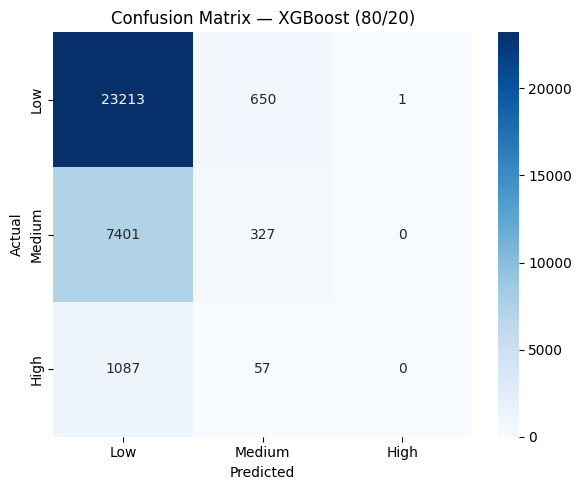

  Confusion matrix saved → cm_XGBoost_80_20.png

  XGBoost — 70/30
  Accuracy         : 0.7202
  F1 (macro)       : 0.3016
  F1 (weighted)    : 0.6259
  ROC-AUC (macro)  : 0.5419

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.73      0.98      0.84     35795
 Medium Risk       0.32      0.04      0.07     11592
   High Risk       0.00      0.00      0.00      1716

    accuracy                           0.72     49103
   macro avg       0.35      0.34      0.30     49103
weighted avg       0.61      0.72      0.63     49103



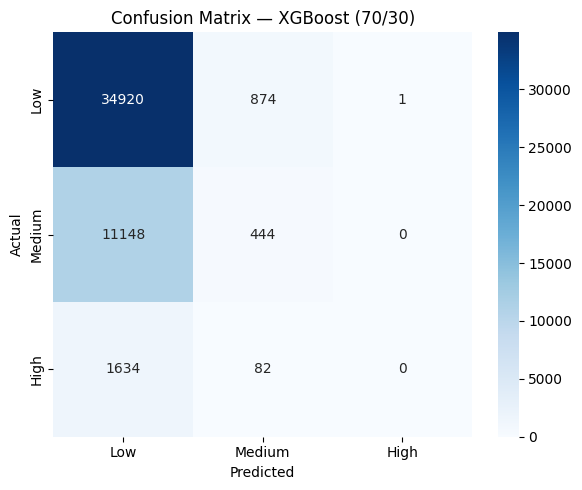

  Confusion matrix saved → cm_XGBoost_70_30.png


In [8]:
# Evaluate XGBoost — both splits 
res_xgb_80 = evaluate_model(xgb_80, X_test_80_tree, y_test_80,
                             'XGBoost', '80/20')
res_xgb_70 = evaluate_model(xgb_70, X_test_70_tree, y_test_70,
                             'XGBoost', '70/30')

results.append(res_xgb_80)
results.append(res_xgb_70)

In [ ]:
# Hyperparameter Tuning — XGBoost (80/20)
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_dist_xgb = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [3, 6, 9],
    'learning_rate'    : [0.01, 0.1, 0.3],
    'subsample'        : [0.8, 1.0],
    'colsample_bytree' : [0.8, 1.0],
    'gamma'            : [0, 0.1, 0.3]
}

xgb_search_80 = RandomizedSearchCV(
    estimator           = XGBClassifier(objective='multi:softprob', num_class=3,
                                        eval_metric='mlogloss',
                                        random_state=42, n_jobs=-1),
    param_distributions = param_dist_xgb,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning XGBoost (80/20)... this may take several minutes.\n")
xgb_search_80.fit(X_train_80_tree_bal, y_train_80_bal)

xgb_tuned_80 = xgb_search_80.best_estimator_

print(f"\nBest parameters (80/20):")
for p, v in xgb_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {xgb_search_80.best_score_:.4f}")

In [ ]:
#  Hyperparameter Tuning — XGBoost (70/30)
xgb_search_70 = RandomizedSearchCV(
    estimator           = XGBClassifier(objective='multi:softprob', num_class=3,
                                        eval_metric='mlogloss',
                                        random_state=42, n_jobs=-1),
    param_distributions = param_dist_xgb,
    n_iter              = 15,
    cv                  = 3,
    scoring             = 'f1_macro',
    random_state        = 42,
    n_jobs              = -1,
    verbose             = 2
)

print("Tuning XGBoost (70/30)... this may take several minutes.\n")
xgb_search_70.fit(X_train_70_tree_bal, y_train_70_bal)

xgb_tuned_70 = xgb_search_70.best_estimator_

print(f"\nBest parameters (70/30):")
for p, v in xgb_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {xgb_search_70.best_score_:.4f}")


  XGBoost Tuned — 80/20
  Accuracy         : 0.7521
  F1 (macro)       : 0.4310
  F1 (weighted)    : 0.7138
  ROC-AUC (macro)  : 0.6950

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.94      0.86     23864
 Medium Risk       0.54      0.28      0.37      7728
   High Risk       0.15      0.04      0.07      1144

    accuracy                           0.75     32736
   macro avg       0.50      0.42      0.43     32736
weighted avg       0.71      0.75      0.71     32736



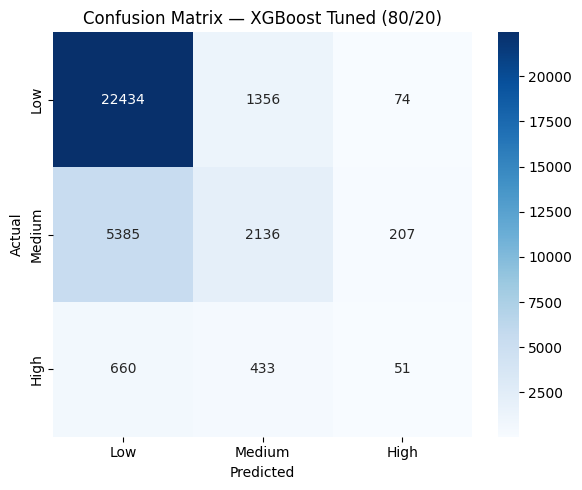

  Confusion matrix saved → cm_XGBoost_Tuned_80_20.png

  XGBoost Tuned — 70/30
  Accuracy         : 0.7496
  F1 (macro)       : 0.4326
  F1 (weighted)    : 0.7117
  ROC-AUC (macro)  : 0.6879

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.94      0.86     35795
 Medium Risk       0.54      0.27      0.36     11592
   High Risk       0.16      0.05      0.08      1716

    accuracy                           0.75     49103
   macro avg       0.50      0.42      0.43     49103
weighted avg       0.71      0.75      0.71     49103



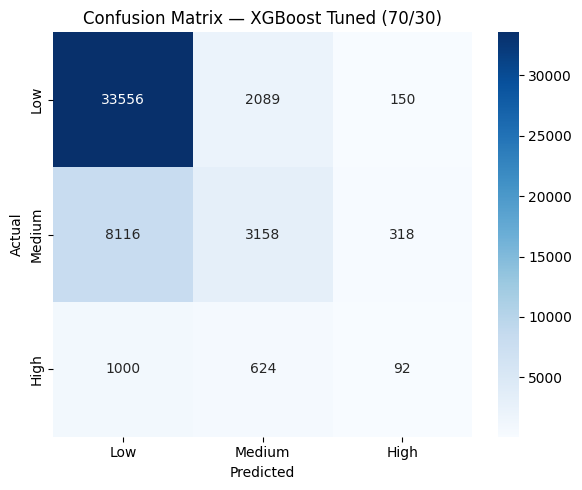

  Confusion matrix saved → cm_XGBoost_Tuned_70_30.png


In [18]:
# Evaluate tuned XGBoost — both splits
res_xgb_tuned_80 = evaluate_model(xgb_tuned_80, X_test_80_tree, y_test_80,
                                   'XGBoost Tuned', '80/20')
res_xgb_tuned_70 = evaluate_model(xgb_tuned_70, X_test_70_tree, y_test_70,
                                   'XGBoost Tuned', '70/30')

results.append(res_xgb_tuned_80)
results.append(res_xgb_tuned_70)

In [19]:
# Compare baseline vs tuned XGBoost
import pandas as pd

xgb_comparison = pd.DataFrame([
    res_xgb_80,         # baseline 80/20
    res_xgb_70,         # baseline 70/30
    res_xgb_tuned_80,   # tuned 80/20
    res_xgb_tuned_70    # tuned 70/30
])

print("XGBoost — Baseline vs Tuned Comparison")
print("=" * 70)
print(xgb_comparison.to_string(index=False))

XGBoost — Baseline vs Tuned Comparison
        Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      XGBoost 80/20    0.7560    0.4369       0.7105   0.7185
      XGBoost 70/30    0.7554    0.4325       0.7102   0.7173
XGBoost Tuned 80/20    0.7521    0.4310       0.7138   0.6950
XGBoost Tuned 70/30    0.7496    0.4326       0.7117   0.6879


3. Logistic Regression

In [20]:
# Train Logistic Regression — 80/20
from sklearn.linear_model import LogisticRegression

lr_80 = LogisticRegression(class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)

print("Training Logistic Regression (80/20)...")
lr_80.fit(X_train_80_lr_bal, y_train_80_bal)
print("Done.")

Training Logistic Regression (80/20)...


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done.


In [21]:
# Train Logistic Regression — 70/30
lr_70 = LogisticRegression(class_weight='balanced',
                            solver='lbfgs', max_iter=1000, random_state=42, n_jobs=-1)

print("Training Logistic Regression (70/30)...")
lr_70.fit(X_train_70_lr_bal, y_train_70_bal)
print("Done.")

Training Logistic Regression (70/30)...


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Done.



  Logistic Regression — 80/20
  Accuracy         : 0.5834
  F1 (macro)       : 0.4048
  F1 (weighted)    : 0.6232
  ROC-AUC (macro)  : 0.6794

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     23864
 Medium Risk       0.29      0.30      0.29      7728
   High Risk       0.10      0.48      0.17      1144

    accuracy                           0.58     32736
   macro avg       0.41      0.49      0.40     32736
weighted avg       0.68      0.58      0.62     32736



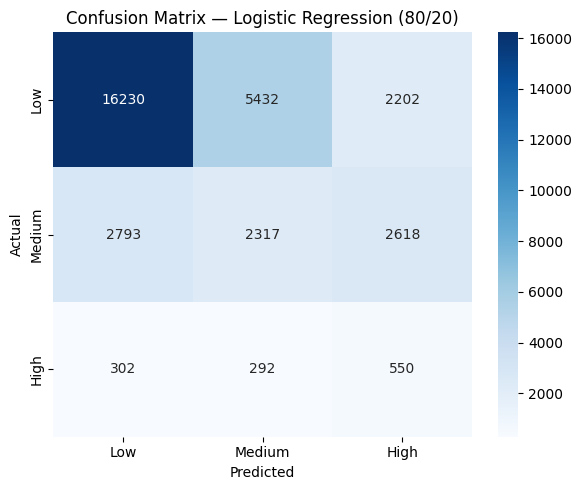

  Confusion matrix saved → cm_Logistic_Regression_80_20.png

  Logistic Regression — 70/30
  Accuracy         : 0.5811
  F1 (macro)       : 0.4041
  F1 (weighted)    : 0.6217
  ROC-AUC (macro)  : 0.6807

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     35795
 Medium Risk       0.29      0.30      0.30     11592
   High Risk       0.10      0.48      0.17      1716

    accuracy                           0.58     49103
   macro avg       0.41      0.49      0.40     49103
weighted avg       0.68      0.58      0.62     49103



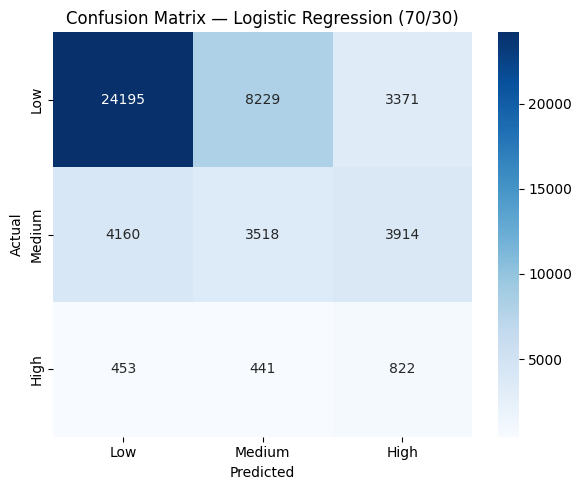

  Confusion matrix saved → cm_Logistic_Regression_70_30.png


In [22]:
# Evaluate Logistic Regression — both splits
res_lr_80 = evaluate_model(lr_80, X_test_80_lr, y_test_80, 'Logistic Regression', '80/20')
res_lr_70 = evaluate_model(lr_70, X_test_70_lr, y_test_70, 'Logistic Regression', '70/30')
results.append(res_lr_80)
results.append(res_lr_70)

In [23]:
# Hyperparameter Tuning — Logistic Regression (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression

param_dist_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [500, 1000],
    'class_weight': ['balanced']
}

lr_search_80 = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, n_jobs=-1),
    param_distributions=param_dist_lr, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Logistic Regression (80/20)...\n")
lr_search_80.fit(X_train_80_lr_bal, y_train_80_bal)
lr_tuned_80 = lr_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in lr_search_80.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {lr_search_80.best_score_:.4f}")

Tuning Logistic Regression (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best parameters (80/20):
  solver               : lbfgs
  max_iter             : 500
  class_weight         : balanced
  C                    : 1

Best CV F1-macro : 0.5344


In [24]:
# Hyperparameter Tuning — Logistic Regression (70/30)
lr_search_70 = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42, n_jobs=-1),
    param_distributions=param_dist_lr, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Logistic Regression (70/30)...\n")
lr_search_70.fit(X_train_70_lr_bal, y_train_70_bal)
lr_tuned_70 = lr_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in lr_search_70.best_params_.items():
    print(f"  {p:<20} : {v}")
print(f"\nBest CV F1-macro : {lr_search_70.best_score_:.4f}")

Tuning Logistic Regression (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)



Best parameters (70/30):
  solver               : saga
  max_iter             : 1000
  class_weight         : balanced
  C                    : 100

Best CV F1-macro : 0.5346


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



  Logistic Regression Tuned — 80/20
  Accuracy         : 0.5834
  F1 (macro)       : 0.4048
  F1 (weighted)    : 0.6232
  ROC-AUC (macro)  : 0.6794

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     23864
 Medium Risk       0.29      0.30      0.29      7728
   High Risk       0.10      0.48      0.17      1144

    accuracy                           0.58     32736
   macro avg       0.41      0.49      0.40     32736
weighted avg       0.68      0.58      0.62     32736



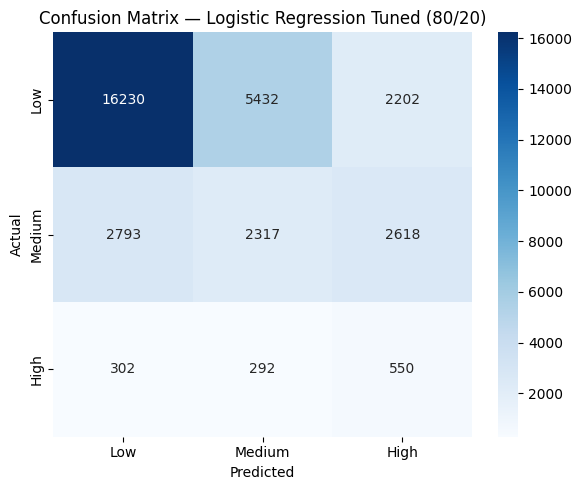

  Confusion matrix saved → cm_Logistic_Regression_Tuned_80_20.png

  Logistic Regression Tuned — 70/30
  Accuracy         : 0.5811
  F1 (macro)       : 0.4035
  F1 (weighted)    : 0.6217
  ROC-AUC (macro)  : 0.6807

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     35795
 Medium Risk       0.29      0.30      0.30     11592
   High Risk       0.10      0.48      0.17      1716

    accuracy                           0.58     49103
   macro avg       0.41      0.48      0.40     49103
weighted avg       0.68      0.58      0.62     49103



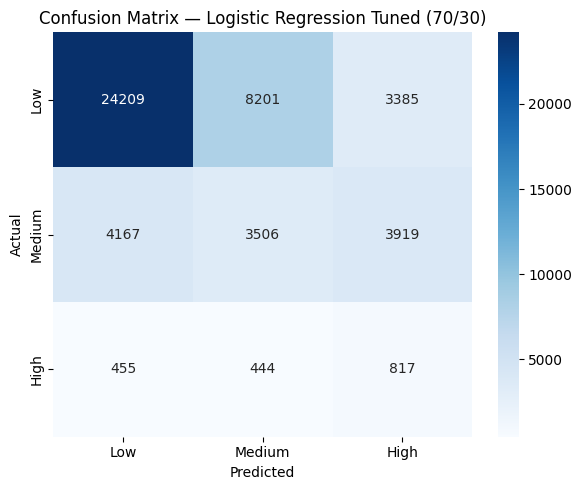

  Confusion matrix saved → cm_Logistic_Regression_Tuned_70_30.png


In [25]:
# Evaluate tuned Logistic Regression — both splits
res_lr_tuned_80 = evaluate_model(lr_tuned_80, X_test_80_lr, y_test_80, 'Logistic Regression Tuned', '80/20')
res_lr_tuned_70 = evaluate_model(lr_tuned_70, X_test_70_lr, y_test_70, 'Logistic Regression Tuned', '70/30')
results.append(res_lr_tuned_80)
results.append(res_lr_tuned_70)

In [26]:
# Logistic Regression — Baseline vs Tuned Comparison
import pandas as pd
lr_comparison = pd.DataFrame([res_lr_80, res_lr_70, res_lr_tuned_80, res_lr_tuned_70])
print("Logistic Regression — Baseline vs Tuned Comparison")
print("=" * 70)
print(lr_comparison.to_string(index=False))

Logistic Regression — Baseline vs Tuned Comparison
                    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Logistic Regression 80/20    0.5834    0.4048       0.6232   0.6794
      Logistic Regression 70/30    0.5811    0.4041       0.6217   0.6807
Logistic Regression Tuned 80/20    0.5834    0.4048       0.6232   0.6794
Logistic Regression Tuned 70/30    0.5811    0.4035       0.6217   0.6807


4. SVM (Support Vector Machine)

In [27]:
# Train SVM — 80/20  (LinearSVC + CalibratedClassifierCV for predict_proba)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_80 = CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42), cv=3)
print("Training SVM (80/20)...")
svm_80.fit(X_train_80_lr_bal, y_train_80_bal)
print("Done.")

Training SVM (80/20)...
Done.


In [28]:
# Train SVM — 70/30
svm_70 = CalibratedClassifierCV(LinearSVC(class_weight='balanced', max_iter=2000, random_state=42), cv=3)
print("Training SVM (70/30)...")
svm_70.fit(X_train_70_lr_bal, y_train_70_bal)
print("Done.")

Training SVM (70/30)...
Done.



  SVM — 80/20
  Accuracy         : 0.5861
  F1 (macro)       : 0.4068
  F1 (weighted)    : 0.6243
  ROC-AUC (macro)  : 0.6763

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     23864
 Medium Risk       0.28      0.30      0.29      7728
   High Risk       0.11      0.48      0.18      1144

    accuracy                           0.59     32736
   macro avg       0.41      0.49      0.41     32736
weighted avg       0.68      0.59      0.62     32736



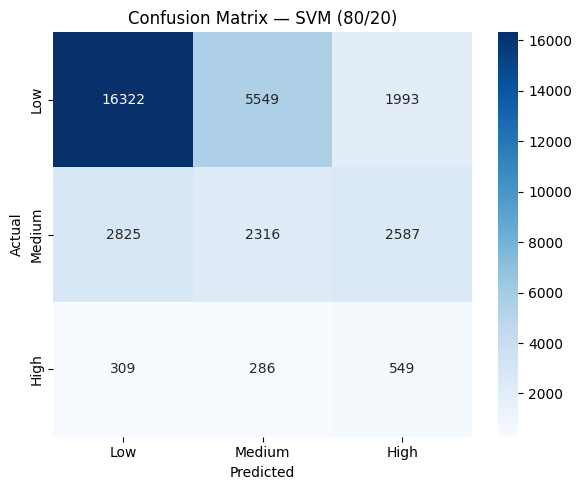

  Confusion matrix saved → cm_SVM_80_20.png

  SVM — 70/30
  Accuracy         : 0.5827
  F1 (macro)       : 0.4049
  F1 (weighted)    : 0.6219
  ROC-AUC (macro)  : 0.6781

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     35795
 Medium Risk       0.28      0.30      0.29     11592
   High Risk       0.11      0.48      0.17      1716

    accuracy                           0.58     49103
   macro avg       0.41      0.49      0.40     49103
weighted avg       0.68      0.58      0.62     49103



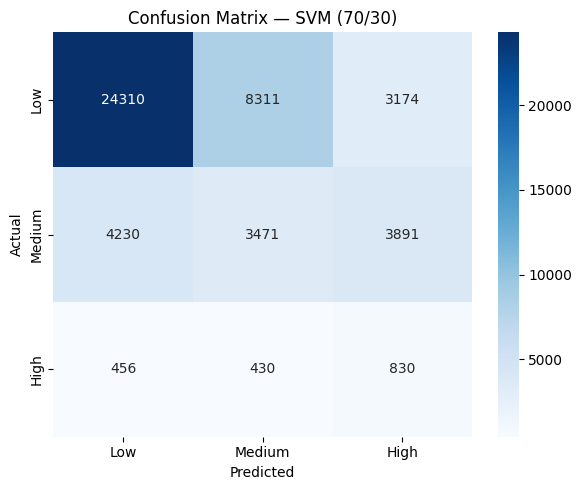

  Confusion matrix saved → cm_SVM_70_30.png


In [29]:
# Evaluate SVM — both splits
res_svm_80 = evaluate_model(svm_80, X_test_80_lr, y_test_80, 'SVM', '80/20')
res_svm_70 = evaluate_model(svm_70, X_test_70_lr, y_test_70, 'SVM', '70/30')
results.append(res_svm_80)
results.append(res_svm_70)

In [30]:
# Hyperparameter Tuning — SVM (80/20)
from sklearn.model_selection import RandomizedSearchCV

param_dist_svm = {
    'estimator__C'           : [0.01, 0.1, 1, 10],
    'estimator__max_iter'    : [1000, 2000],
    'estimator__class_weight': ['balanced']
}

svm_search_80 = RandomizedSearchCV(
    estimator=CalibratedClassifierCV(LinearSVC(random_state=42), cv=3),
    param_distributions=param_dist_svm, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning SVM (80/20)...\n")
svm_search_80.fit(X_train_80_lr_bal, y_train_80_bal)
svm_tuned_80 = svm_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in svm_search_80.best_params_.items():
    print(f"  {p:<30} : {v}")
print(f"\nBest CV F1-macro : {svm_search_80.best_score_:.4f}")

Tuning SVM (80/20)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best parameters (80/20):
  estimator__max_iter            : 1000
  estimator__class_weight        : balanced
  estimator__C                   : 0.1

Best CV F1-macro : 0.5346


In [31]:
# Hyperparameter Tuning — SVM (70/30)
svm_search_70 = RandomizedSearchCV(
    estimator=CalibratedClassifierCV(LinearSVC(random_state=42), cv=3),
    param_distributions=param_dist_svm, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning SVM (70/30)...\n")
svm_search_70.fit(X_train_70_lr_bal, y_train_70_bal)
svm_tuned_70 = svm_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in svm_search_70.best_params_.items():
    print(f"  {p:<30} : {v}")
print(f"\nBest CV F1-macro : {svm_search_70.best_score_:.4f}")

Tuning SVM (70/30)...

Fitting 3 folds for each of 8 candidates, totalling 24 fits


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 8 is smaller than n_iter=10. Running 8 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



Best parameters (70/30):
  estimator__max_iter            : 1000
  estimator__class_weight        : balanced
  estimator__C                   : 0.01

Best CV F1-macro : 0.5334



  SVM Tuned — 80/20
  Accuracy         : 0.5861
  F1 (macro)       : 0.4067
  F1 (weighted)    : 0.6243
  ROC-AUC (macro)  : 0.6762

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     23864
 Medium Risk       0.28      0.30      0.29      7728
   High Risk       0.11      0.48      0.17      1144

    accuracy                           0.59     32736
   macro avg       0.41      0.49      0.41     32736
weighted avg       0.68      0.59      0.62     32736



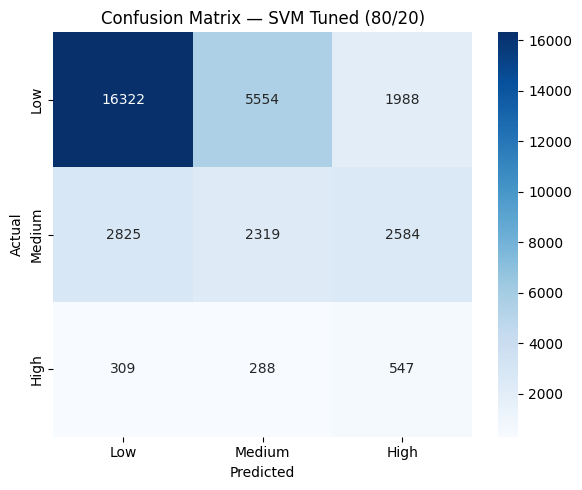

  Confusion matrix saved → cm_SVM_Tuned_80_20.png

  SVM Tuned — 70/30
  Accuracy         : 0.5821
  F1 (macro)       : 0.4049
  F1 (weighted)    : 0.6213
  ROC-AUC (macro)  : 0.6780

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.84      0.68      0.75     35795
 Medium Risk       0.28      0.30      0.29     11592
   High Risk       0.11      0.49      0.17      1716

    accuracy                           0.58     49103
   macro avg       0.41      0.49      0.40     49103
weighted avg       0.68      0.58      0.62     49103



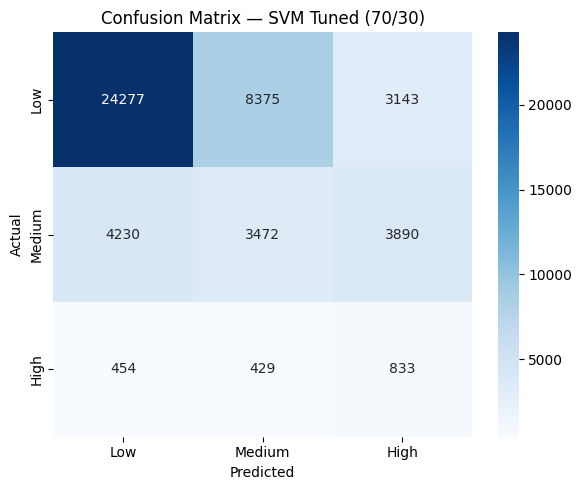

  Confusion matrix saved → cm_SVM_Tuned_70_30.png


In [32]:
# Evaluate tuned SVM — both splits
res_svm_tuned_80 = evaluate_model(svm_tuned_80, X_test_80_lr, y_test_80, 'SVM Tuned', '80/20')
res_svm_tuned_70 = evaluate_model(svm_tuned_70, X_test_70_lr, y_test_70, 'SVM Tuned', '70/30')
results.append(res_svm_tuned_80)
results.append(res_svm_tuned_70)

In [33]:
# SVM — Baseline vs Tuned Comparison
import pandas as pd
svm_comparison = pd.DataFrame([res_svm_80, res_svm_70, res_svm_tuned_80, res_svm_tuned_70])
print("SVM — Baseline vs Tuned Comparison")
print("=" * 70)
print(svm_comparison.to_string(index=False))

SVM — Baseline vs Tuned Comparison
    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      SVM 80/20    0.5861    0.4068       0.6243   0.6763
      SVM 70/30    0.5827    0.4049       0.6219   0.6781
SVM Tuned 80/20    0.5861    0.4067       0.6243   0.6762
SVM Tuned 70/30    0.5821    0.4049       0.6213   0.6780


5. Gradient Boosting

In [34]:
# Train Gradient Boosting — 80/20
from sklearn.ensemble import GradientBoostingClassifier

gb_80 = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
print("Training Gradient Boosting (80/20)...")
gb_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Gradient Boosting (80/20)...
Done.


In [35]:
# Train Gradient Boosting — 70/30
gb_70 = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
print("Training Gradient Boosting (70/30)...")
gb_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Gradient Boosting (70/30)...
Done.



  Gradient Boosting — 80/20
  Accuracy         : 0.7222
  F1 (macro)       : 0.4539
  F1 (weighted)    : 0.7018
  ROC-AUC (macro)  : 0.7126

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.89      0.84     23864
 Medium Risk       0.44      0.27      0.34      7728
   High Risk       0.17      0.20      0.18      1144

    accuracy                           0.72     32736
   macro avg       0.47      0.45      0.45     32736
weighted avg       0.69      0.72      0.70     32736



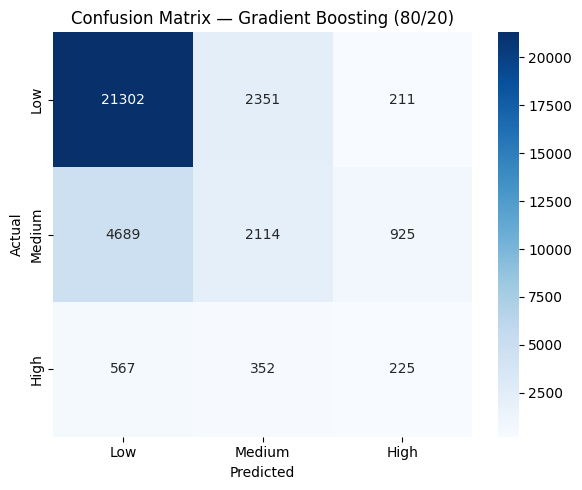

  Confusion matrix saved → cm_Gradient_Boosting_80_20.png

  Gradient Boosting — 70/30
  Accuracy         : 0.7263
  F1 (macro)       : 0.4497
  F1 (weighted)    : 0.7005
  ROC-AUC (macro)  : 0.7128

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.80      0.91      0.85     35795
 Medium Risk       0.45      0.25      0.32     11592
   High Risk       0.17      0.20      0.18      1716

    accuracy                           0.73     49103
   macro avg       0.47      0.45      0.45     49103
weighted avg       0.69      0.73      0.70     49103



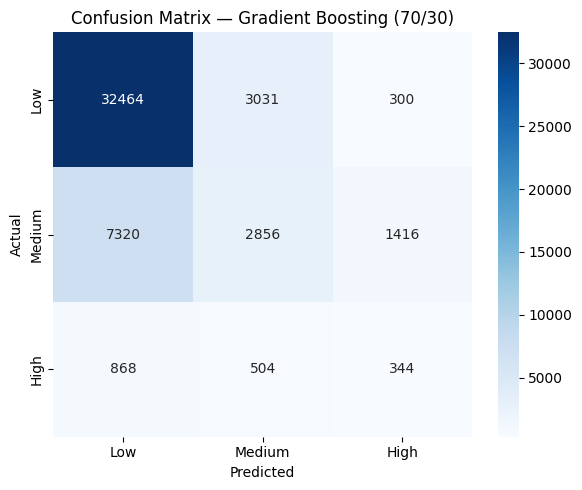

  Confusion matrix saved → cm_Gradient_Boosting_70_30.png


In [36]:
# Evaluate Gradient Boosting — both splits
res_gb_80 = evaluate_model(gb_80, X_test_80_tree, y_test_80, 'Gradient Boosting', '80/20')
res_gb_70 = evaluate_model(gb_70, X_test_70_tree, y_test_70, 'Gradient Boosting', '70/30')
results.append(res_gb_80)
results.append(res_gb_70)

In [38]:
# Hyperparameter Tuning — Gradient Boosting (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

param_dist_gb = {
    'n_estimators': [100, 200, 300], 'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3], 'subsample': [0.8, 1.0], 'min_samples_split': [2, 5]
}

gb_search_80 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Gradient Boosting (80/20)...\n")
gb_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
gb_tuned_80 = gb_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in gb_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {gb_search_80.best_score_:.4f}")

Tuning Gradient Boosting (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits


KeyboardInterrupt: 

In [ ]:
# Hyperparameter Tuning — Gradient Boosting (70/30)
gb_search_70 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=param_dist_gb, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Gradient Boosting (70/30)...\n")
gb_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
gb_tuned_70 = gb_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in gb_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {gb_search_70.best_score_:.4f}")

In [ ]:
# Evaluate tuned Gradient Boosting — both splits
res_gb_tuned_80 = evaluate_model(gb_tuned_80, X_test_80_tree, y_test_80, 'Gradient Boosting Tuned', '80/20')
res_gb_tuned_70 = evaluate_model(gb_tuned_70, X_test_70_tree, y_test_70, 'Gradient Boosting Tuned', '70/30')
results.append(res_gb_tuned_80)
results.append(res_gb_tuned_70)

In [ ]:
# Gradient Boosting — Baseline vs Tuned Comparison
import pandas as pd
gb_comparison = pd.DataFrame([res_gb_80, res_gb_70, res_gb_tuned_80, res_gb_tuned_70])
print("Gradient Boosting — Baseline vs Tuned Comparison")
print("=" * 70)
print(gb_comparison.to_string(index=False))

6. Decision Tree

In [39]:
# Train Decision Tree — 80/20
from sklearn.tree import DecisionTreeClassifier

dt_80 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
print("Training Decision Tree (80/20)...")
dt_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Decision Tree (80/20)...
Done.


In [40]:
# Train Decision Tree — 70/30
dt_70 = DecisionTreeClassifier(class_weight='balanced', random_state=42)
print("Training Decision Tree (70/30)...")
dt_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Decision Tree (70/30)...
Done.



  Decision Tree — 80/20
  Accuracy         : 0.6649
  F1 (macro)       : 0.4034
  F1 (weighted)    : 0.6607
  ROC-AUC (macro)  : 0.5710

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     23864
 Medium Risk       0.35      0.32      0.34      7728
   High Risk       0.08      0.08      0.08      1144

    accuracy                           0.66     32736
   macro avg       0.40      0.40      0.40     32736
weighted avg       0.66      0.66      0.66     32736



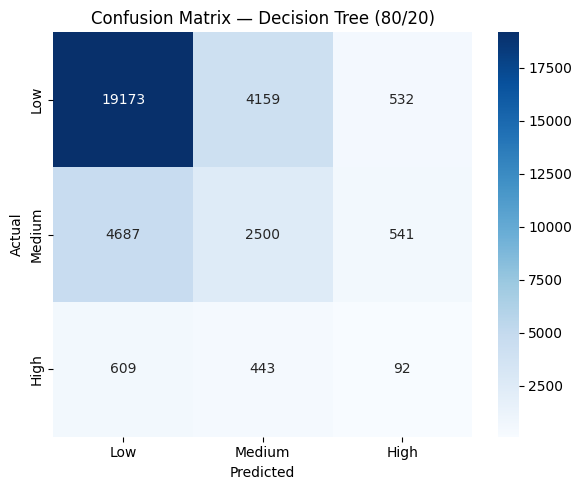

  Confusion matrix saved → cm_Decision_Tree_80_20.png

  Decision Tree — 70/30
  Accuracy         : 0.6639
  F1 (macro)       : 0.4082
  F1 (weighted)    : 0.6594
  ROC-AUC (macro)  : 0.5718

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     35795
 Medium Risk       0.35      0.32      0.33     11592
   High Risk       0.10      0.10      0.10      1716

    accuracy                           0.66     49103
   macro avg       0.41      0.41      0.41     49103
weighted avg       0.66      0.66      0.66     49103



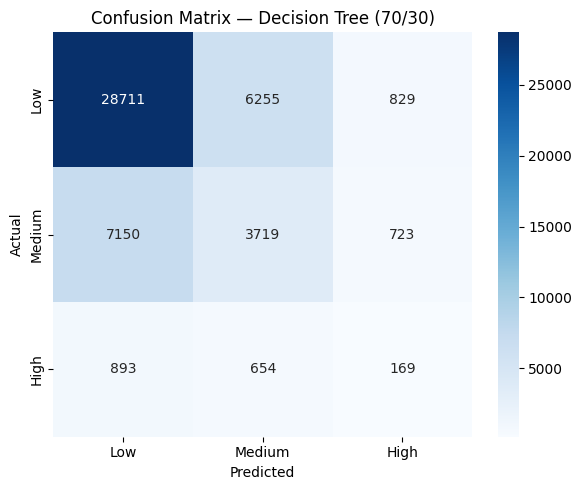

  Confusion matrix saved → cm_Decision_Tree_70_30.png


In [41]:
# Evaluate Decision Tree — both splits
res_dt_80 = evaluate_model(dt_80, X_test_80_tree, y_test_80, 'Decision Tree', '80/20')
res_dt_70 = evaluate_model(dt_70, X_test_70_tree, y_test_70, 'Decision Tree', '70/30')
results.append(res_dt_80)
results.append(res_dt_70)

In [42]:
# Hyperparameter Tuning — Decision Tree (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist_dt = {
    'max_depth': [None, 5, 10, 20], 'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4], 'criterion': ['gini', 'entropy'], 'class_weight': ['balanced']
}

dt_search_80 = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Decision Tree (80/20)...\n")
dt_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
dt_tuned_80 = dt_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in dt_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {dt_search_80.best_score_:.4f}")

Tuning Decision Tree (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  min_samples_split      : 2
  min_samples_leaf       : 1
  max_depth              : None
  criterion              : gini
  class_weight           : balanced

Best CV F1-macro : 0.7604


In [43]:
# Hyperparameter Tuning — Decision Tree (70/30)
dt_search_70 = RandomizedSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_distributions=param_dist_dt, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Decision Tree (70/30)...\n")
dt_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
dt_tuned_70 = dt_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in dt_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {dt_search_70.best_score_:.4f}")

Tuning Decision Tree (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  min_samples_split      : 2
  min_samples_leaf       : 1
  max_depth              : None
  criterion              : gini
  class_weight           : balanced

Best CV F1-macro : 0.7623



  Decision Tree Tuned — 80/20
  Accuracy         : 0.6649
  F1 (macro)       : 0.4034
  F1 (weighted)    : 0.6607
  ROC-AUC (macro)  : 0.5710

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     23864
 Medium Risk       0.35      0.32      0.34      7728
   High Risk       0.08      0.08      0.08      1144

    accuracy                           0.66     32736
   macro avg       0.40      0.40      0.40     32736
weighted avg       0.66      0.66      0.66     32736



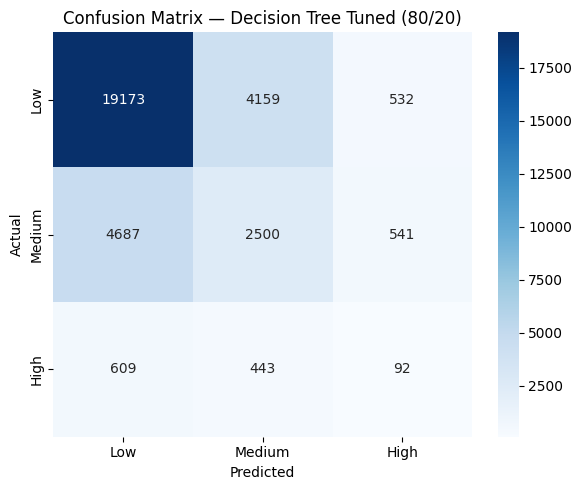

  Confusion matrix saved → cm_Decision_Tree_Tuned_80_20.png

  Decision Tree Tuned — 70/30
  Accuracy         : 0.6639
  F1 (macro)       : 0.4082
  F1 (weighted)    : 0.6594
  ROC-AUC (macro)  : 0.5718

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.80      0.79     35795
 Medium Risk       0.35      0.32      0.33     11592
   High Risk       0.10      0.10      0.10      1716

    accuracy                           0.66     49103
   macro avg       0.41      0.41      0.41     49103
weighted avg       0.66      0.66      0.66     49103



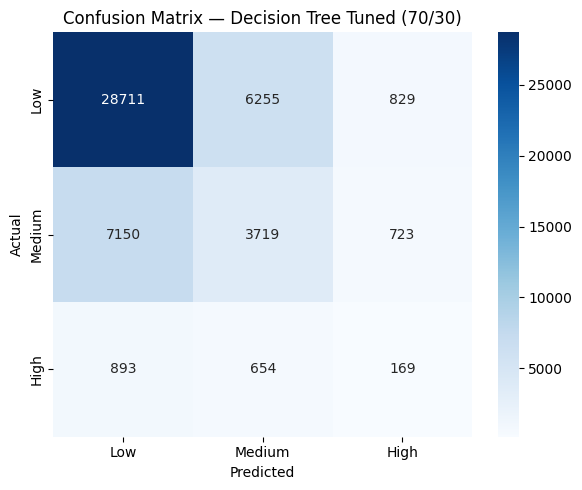

  Confusion matrix saved → cm_Decision_Tree_Tuned_70_30.png


In [44]:
# Evaluate tuned Decision Tree — both splits
res_dt_tuned_80 = evaluate_model(dt_tuned_80, X_test_80_tree, y_test_80, 'Decision Tree Tuned', '80/20')
res_dt_tuned_70 = evaluate_model(dt_tuned_70, X_test_70_tree, y_test_70, 'Decision Tree Tuned', '70/30')
results.append(res_dt_tuned_80)
results.append(res_dt_tuned_70)

In [45]:
# Decision Tree — Baseline vs Tuned Comparison
import pandas as pd
dt_comparison = pd.DataFrame([res_dt_80, res_dt_70, res_dt_tuned_80, res_dt_tuned_70])
print("Decision Tree — Baseline vs Tuned Comparison")
print("=" * 70)
print(dt_comparison.to_string(index=False))

Decision Tree — Baseline vs Tuned Comparison
              Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Decision Tree 80/20    0.6649    0.4034       0.6607   0.5710
      Decision Tree 70/30    0.6639    0.4082       0.6594   0.5718
Decision Tree Tuned 80/20    0.6649    0.4034       0.6607   0.5710
Decision Tree Tuned 70/30    0.6639    0.4082       0.6594   0.5718


7. KNN (K-Nearest Neighbors)

In [46]:
# Train KNN — 80/20
from sklearn.neighbors import KNeighborsClassifier

knn_80 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training KNN (80/20)...")
knn_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training KNN (80/20)...
Done.


In [47]:
# Train KNN — 70/30
knn_70 = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("Training KNN (70/30)...")
knn_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training KNN (70/30)...
Done.



  KNN — 80/20
  Accuracy         : 0.5818
  F1 (macro)       : 0.3975
  F1 (weighted)    : 0.6134
  ROC-AUC (macro)  : 0.6047

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.81      0.65      0.72     23864
 Medium Risk       0.30      0.43      0.36      7728
   High Risk       0.08      0.19      0.12      1144

    accuracy                           0.58     32736
   macro avg       0.40      0.42      0.40     32736
weighted avg       0.66      0.58      0.61     32736



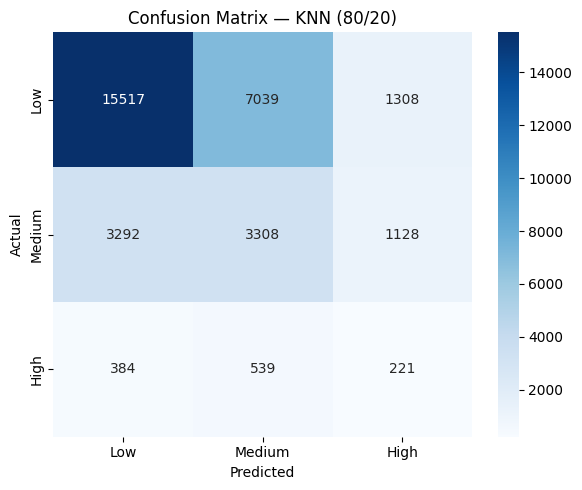

  Confusion matrix saved → cm_KNN_80_20.png

  KNN — 70/30
  Accuracy         : 0.5756
  F1 (macro)       : 0.3916
  F1 (weighted)    : 0.6082
  ROC-AUC (macro)  : 0.6037

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.81      0.64      0.71     35795
 Medium Risk       0.30      0.43      0.35     11592
   High Risk       0.08      0.18      0.11      1716

    accuracy                           0.58     49103
   macro avg       0.39      0.42      0.39     49103
weighted avg       0.66      0.58      0.61     49103



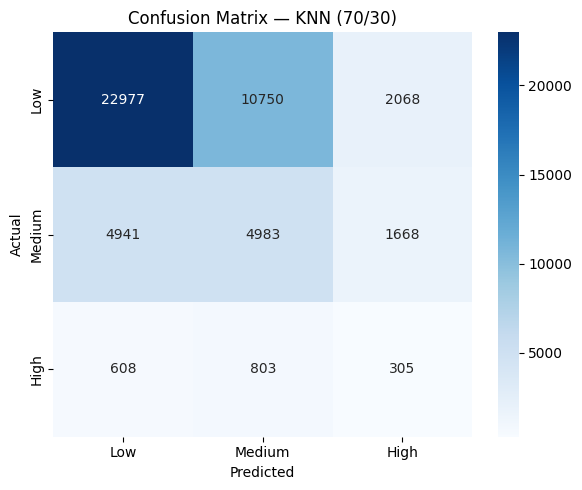

  Confusion matrix saved → cm_KNN_70_30.png


In [48]:
# Evaluate KNN — both splits
res_knn_80 = evaluate_model(knn_80, X_test_80_tree, y_test_80, 'KNN', '80/20')
res_knn_70 = evaluate_model(knn_70, X_test_70_tree, y_test_70, 'KNN', '70/30')
results.append(res_knn_80)
results.append(res_knn_70)

In [49]:
# Hyperparameter Tuning — KNN (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier

param_dist_knn = {
    'n_neighbors': [3, 5, 7, 11, 15], 'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

knn_search_80 = RandomizedSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=param_dist_knn, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning KNN (80/20)...\n")
knn_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
knn_tuned_80 = knn_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in knn_search_80.best_params_.items():
    print(f"  {p:<15} : {v}")
print(f"\nBest CV F1-macro : {knn_search_80.best_score_:.4f}")

Tuning KNN (80/20)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters (80/20):
  weights         : distance
  n_neighbors     : 3
  metric          : manhattan

Best CV F1-macro : 0.8052


In [50]:
# Hyperparameter Tuning — KNN (70/30)
knn_search_70 = RandomizedSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_distributions=param_dist_knn, n_iter=10, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning KNN (70/30)...\n")
knn_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
knn_tuned_70 = knn_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in knn_search_70.best_params_.items():
    print(f"  {p:<15} : {v}")
print(f"\nBest CV F1-macro : {knn_search_70.best_score_:.4f}")

Tuning KNN (70/30)...

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters (70/30):
  weights         : distance
  n_neighbors     : 3
  metric          : manhattan

Best CV F1-macro : 0.8108



  KNN Tuned — 80/20
  Accuracy         : 0.6547
  F1 (macro)       : 0.4124
  F1 (weighted)    : 0.6580
  ROC-AUC (macro)  : 0.5939

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.78      0.79     23864
 Medium Risk       0.35      0.35      0.35      7728
   High Risk       0.09      0.12      0.10      1144

    accuracy                           0.65     32736
   macro avg       0.41      0.42      0.41     32736
weighted avg       0.66      0.65      0.66     32736



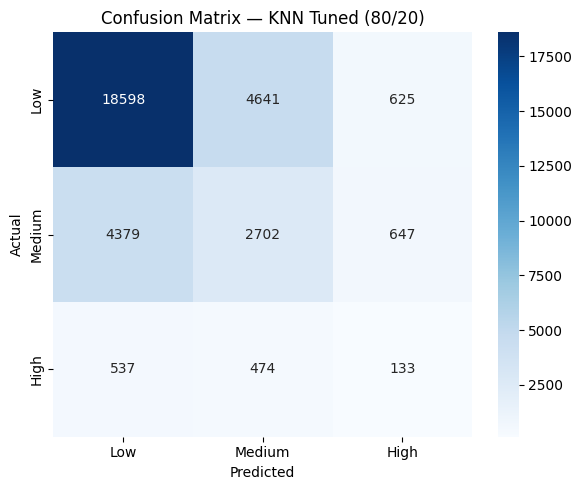

  Confusion matrix saved → cm_KNN_Tuned_80_20.png

  KNN Tuned — 70/30
  Accuracy         : 0.6495
  F1 (macro)       : 0.4087
  F1 (weighted)    : 0.6541
  ROC-AUC (macro)  : 0.5933

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.77      0.78     35795
 Medium Risk       0.34      0.35      0.34     11592
   High Risk       0.09      0.12      0.10      1716

    accuracy                           0.65     49103
   macro avg       0.41      0.41      0.41     49103
weighted avg       0.66      0.65      0.65     49103



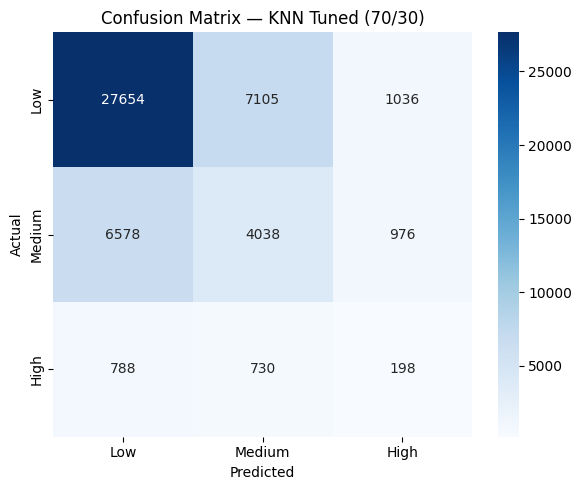

  Confusion matrix saved → cm_KNN_Tuned_70_30.png


In [51]:
# Evaluate tuned KNN — both splits
res_knn_tuned_80 = evaluate_model(knn_tuned_80, X_test_80_tree, y_test_80, 'KNN Tuned', '80/20')
res_knn_tuned_70 = evaluate_model(knn_tuned_70, X_test_70_tree, y_test_70, 'KNN Tuned', '70/30')
results.append(res_knn_tuned_80)
results.append(res_knn_tuned_70)

In [52]:
# KNN — Baseline vs Tuned Comparison
import pandas as pd
knn_comparison = pd.DataFrame([res_knn_80, res_knn_70, res_knn_tuned_80, res_knn_tuned_70])
print("KNN — Baseline vs Tuned Comparison")
print("=" * 70)
print(knn_comparison.to_string(index=False))

KNN — Baseline vs Tuned Comparison
    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      KNN 80/20    0.5818    0.3975       0.6134   0.6047
      KNN 70/30    0.5756    0.3916       0.6082   0.6037
KNN Tuned 80/20    0.6547    0.4124       0.6580   0.5939
KNN Tuned 70/30    0.6495    0.4087       0.6541   0.5933


8. Extra Trees

In [53]:
# Train Extra Trees — 80/20
from sklearn.ensemble import ExtraTreesClassifier

et_80 = ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
print("Training Extra Trees (80/20)...")
et_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training Extra Trees (80/20)...
Done.


In [54]:
# Train Extra Trees — 70/30
et_70 = ExtraTreesClassifier(n_estimators=200, class_weight='balanced', random_state=42, n_jobs=-1)
print("Training Extra Trees (70/30)...")
et_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training Extra Trees (70/30)...
Done.



  Extra Trees — 80/20
  Accuracy         : 0.7052
  F1 (macro)       : 0.4190
  F1 (weighted)    : 0.6863
  ROC-AUC (macro)  : 0.6430

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     23864
 Medium Risk       0.41      0.31      0.35      7728
   High Risk       0.11      0.06      0.08      1144

    accuracy                           0.71     32736
   macro avg       0.44      0.41      0.42     32736
weighted avg       0.67      0.71      0.69     32736



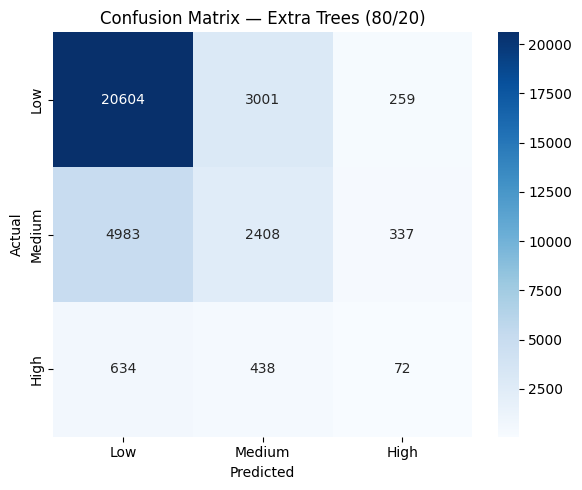

  Confusion matrix saved → cm_Extra_Trees_80_20.png

  Extra Trees — 70/30
  Accuracy         : 0.7023
  F1 (macro)       : 0.4162
  F1 (weighted)    : 0.6834
  ROC-AUC (macro)  : 0.6435

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.86      0.82     35795
 Medium Risk       0.40      0.31      0.35     11592
   High Risk       0.11      0.06      0.08      1716

    accuracy                           0.70     49103
   macro avg       0.43      0.41      0.42     49103
weighted avg       0.67      0.70      0.68     49103



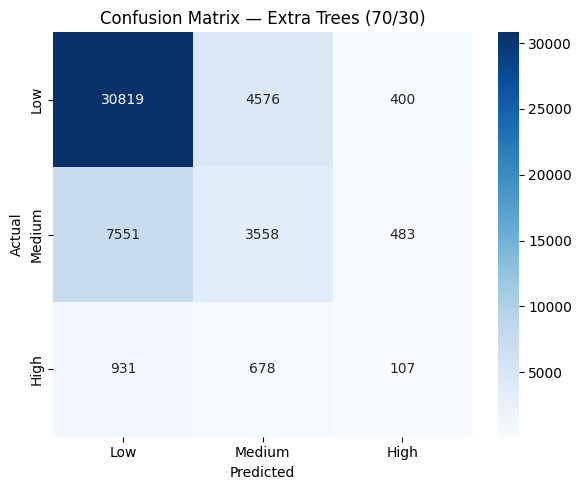

  Confusion matrix saved → cm_Extra_Trees_70_30.png


In [55]:
# Evaluate Extra Trees — both splits
res_et_80 = evaluate_model(et_80, X_test_80_tree, y_test_80, 'Extra Trees', '80/20')
res_et_70 = evaluate_model(et_70, X_test_70_tree, y_test_70, 'Extra Trees', '70/30')
results.append(res_et_80)
results.append(res_et_70)

In [56]:
# Hyperparameter Tuning — Extra Trees (80/20)
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import ExtraTreesClassifier

param_dist_et = {
    'n_estimators': [100, 200, 300], 'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5], 'max_features': ['sqrt', 'log2'], 'class_weight': ['balanced']
}

et_search_80 = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_et, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Extra Trees (80/20)...\n")
et_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
et_tuned_80 = et_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in et_search_80.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {et_search_80.best_score_:.4f}")

Tuning Extra Trees (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  n_estimators           : 300
  min_samples_split      : 2
  max_features           : log2
  max_depth              : None
  class_weight           : balanced

Best CV F1-macro : 0.8422


In [57]:
# Hyperparameter Tuning — Extra Trees (70/30)
et_search_70 = RandomizedSearchCV(
    estimator=ExtraTreesClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist_et, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning Extra Trees (70/30)...\n")
et_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
et_tuned_70 = et_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in et_search_70.best_params_.items():
    print(f"  {p:<22} : {v}")
print(f"\nBest CV F1-macro : {et_search_70.best_score_:.4f}")

Tuning Extra Trees (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  n_estimators           : 300
  min_samples_split      : 2
  max_features           : log2
  max_depth              : None
  class_weight           : balanced

Best CV F1-macro : 0.8461



  Extra Trees Tuned — 80/20
  Accuracy         : 0.7056
  F1 (macro)       : 0.4197
  F1 (weighted)    : 0.6869
  ROC-AUC (macro)  : 0.6431

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.86      0.82     23864
 Medium Risk       0.41      0.31      0.36      7728
   High Risk       0.11      0.06      0.08      1144

    accuracy                           0.71     32736
   macro avg       0.44      0.41      0.42     32736
weighted avg       0.67      0.71      0.69     32736



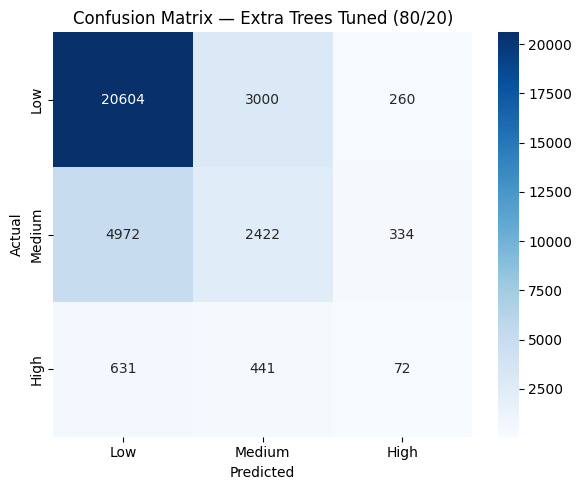

  Confusion matrix saved → cm_Extra_Trees_Tuned_80_20.png

  Extra Trees Tuned — 70/30
  Accuracy         : 0.7027
  F1 (macro)       : 0.4167
  F1 (weighted)    : 0.6839
  ROC-AUC (macro)  : 0.6442

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.86      0.82     35795
 Medium Risk       0.40      0.31      0.35     11592
   High Risk       0.11      0.06      0.08      1716

    accuracy                           0.70     49103
   macro avg       0.43      0.41      0.42     49103
weighted avg       0.67      0.70      0.68     49103



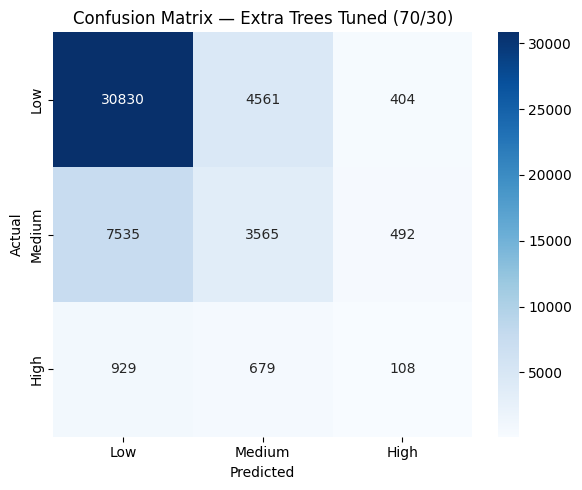

  Confusion matrix saved → cm_Extra_Trees_Tuned_70_30.png


In [58]:
# Evaluate tuned Extra Trees — both splits
res_et_tuned_80 = evaluate_model(et_tuned_80, X_test_80_tree, y_test_80, 'Extra Trees Tuned', '80/20')
res_et_tuned_70 = evaluate_model(et_tuned_70, X_test_70_tree, y_test_70, 'Extra Trees Tuned', '70/30')
results.append(res_et_tuned_80)
results.append(res_et_tuned_70)

In [59]:
# Extra Trees — Baseline vs Tuned Comparison
import pandas as pd
et_comparison = pd.DataFrame([res_et_80, res_et_70, res_et_tuned_80, res_et_tuned_70])
print("Extra Trees — Baseline vs Tuned Comparison")
print("=" * 70)
print(et_comparison.to_string(index=False))

Extra Trees — Baseline vs Tuned Comparison
            Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      Extra Trees 80/20    0.7052    0.4190       0.6863   0.6430
      Extra Trees 70/30    0.7023    0.4162       0.6834   0.6435
Extra Trees Tuned 80/20    0.7056    0.4197       0.6869   0.6431
Extra Trees Tuned 70/30    0.7027    0.4167       0.6839   0.6442


9. LightGBM

In [60]:
# Train LightGBM — 80/20
from lightgbm import LGBMClassifier

lgbm_80 = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
print("Training LightGBM (80/20)...")
lgbm_80.fit(X_train_80_tree_bal, y_train_80_bal)
print("Done.")

Training LightGBM (80/20)...
Done.


In [61]:
# Train LightGBM — 70/30
lgbm_70 = LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1, verbose=-1)
print("Training LightGBM (70/30)...")
lgbm_70.fit(X_train_70_tree_bal, y_train_70_bal)
print("Done.")

Training LightGBM (70/30)...
Done.


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM — 80/20
  Accuracy         : 0.7512
  F1 (macro)       : 0.4346
  F1 (weighted)    : 0.7014
  ROC-AUC (macro)  : 0.7262

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.97      0.87     23864
 Medium Risk       0.58      0.18      0.27      7728
   High Risk       0.17      0.16      0.16      1144

    accuracy                           0.75     32736
   macro avg       0.51      0.43      0.43     32736
weighted avg       0.72      0.75      0.70     32736



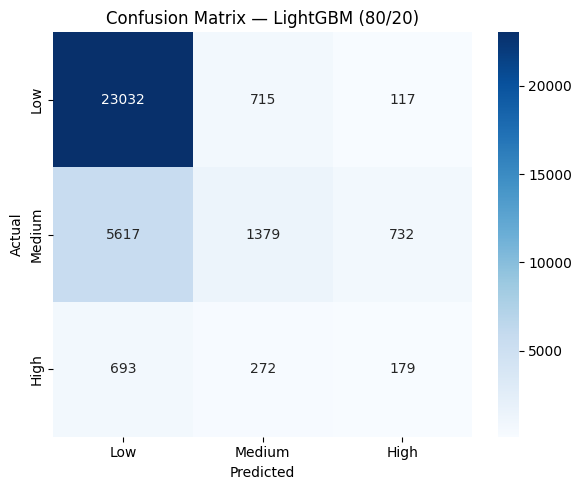

c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Confusion matrix saved → cm_LightGBM_80_20.png


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM — 70/30
  Accuracy         : 0.7517
  F1 (macro)       : 0.4323
  F1 (weighted)    : 0.7011
  ROC-AUC (macro)  : 0.7257

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.78      0.97      0.87     35795
 Medium Risk       0.59      0.18      0.27     11592
   High Risk       0.17      0.15      0.16      1716

    accuracy                           0.75     49103
   macro avg       0.51      0.43      0.43     49103
weighted avg       0.72      0.75      0.70     49103



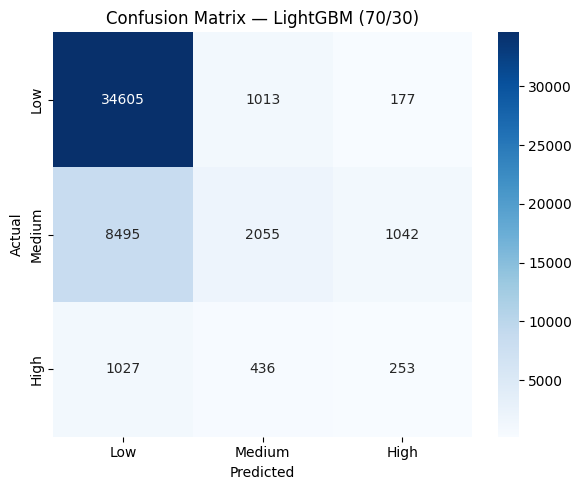

  Confusion matrix saved → cm_LightGBM_70_30.png


In [62]:
# Evaluate LightGBM — both splits
res_lgbm_80 = evaluate_model(lgbm_80, X_test_80_tree, y_test_80, 'LightGBM', '80/20')
res_lgbm_70 = evaluate_model(lgbm_70, X_test_70_tree, y_test_70, 'LightGBM', '70/30')
results.append(res_lgbm_80)
results.append(res_lgbm_70)

In [63]:
# Hyperparameter Tuning — LightGBM (80/20)
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMClassifier

param_dist_lgbm = {
    'n_estimators': [100, 200, 300], 'max_depth': [-1, 6, 10],
    'learning_rate': [0.01, 0.1, 0.3], 'num_leaves': [31, 63, 127], 'class_weight': ['balanced']
}

lgbm_search_80 = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning LightGBM (80/20)...\n")
lgbm_search_80.fit(X_train_80_tree_bal, y_train_80_bal)
lgbm_tuned_80 = lgbm_search_80.best_estimator_
print(f"\nBest parameters (80/20):")
for p, v in lgbm_search_80.best_params_.items():
    print(f"  {p:<18} : {v}")
print(f"\nBest CV F1-macro : {lgbm_search_80.best_score_:.4f}")

Tuning LightGBM (80/20)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (80/20):
  num_leaves         : 127
  n_estimators       : 300
  max_depth          : -1
  learning_rate      : 0.1
  class_weight       : balanced

Best CV F1-macro : 0.7714


In [64]:
# Hyperparameter Tuning — LightGBM (70/30)
lgbm_search_70 = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1),
    param_distributions=param_dist_lgbm, n_iter=15, cv=3,
    scoring='f1_macro', random_state=42, n_jobs=-1, verbose=1)

print("Tuning LightGBM (70/30)...\n")
lgbm_search_70.fit(X_train_70_tree_bal, y_train_70_bal)
lgbm_tuned_70 = lgbm_search_70.best_estimator_
print(f"\nBest parameters (70/30):")
for p, v in lgbm_search_70.best_params_.items():
    print(f"  {p:<18} : {v}")
print(f"\nBest CV F1-macro : {lgbm_search_70.best_score_:.4f}")

Tuning LightGBM (70/30)...

Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best parameters (70/30):
  num_leaves         : 127
  n_estimators       : 300
  max_depth          : -1
  learning_rate      : 0.1
  class_weight       : balanced

Best CV F1-macro : 0.7782


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM Tuned — 80/20
  Accuracy         : 0.7599
  F1 (macro)       : 0.4326
  F1 (weighted)    : 0.7155
  ROC-AUC (macro)  : 0.7161

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     23864
 Medium Risk       0.59      0.25      0.35      7728
   High Risk       0.18      0.05      0.08      1144

    accuracy                           0.76     32736
   macro avg       0.52      0.42      0.43     32736
weighted avg       0.72      0.76      0.72     32736



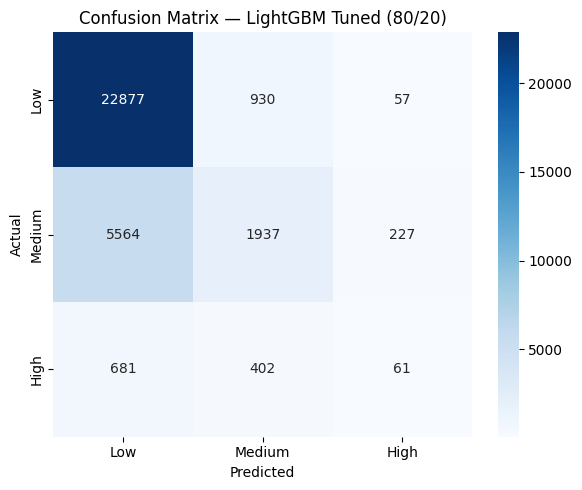

  Confusion matrix saved → cm_LightGBM_Tuned_80_20.png


c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Deep Learning\Lab 2 - Data Exploration\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



  LightGBM Tuned — 70/30
  Accuracy         : 0.7597
  F1 (macro)       : 0.4284
  F1 (weighted)    : 0.7158
  ROC-AUC (macro)  : 0.7133

  Classification Report:
              precision    recall  f1-score   support

    Low Risk       0.79      0.96      0.86     35795
 Medium Risk       0.59      0.26      0.36     11592
   High Risk       0.16      0.04      0.06      1716

    accuracy                           0.76     49103
   macro avg       0.51      0.42      0.43     49103
weighted avg       0.72      0.76      0.72     49103



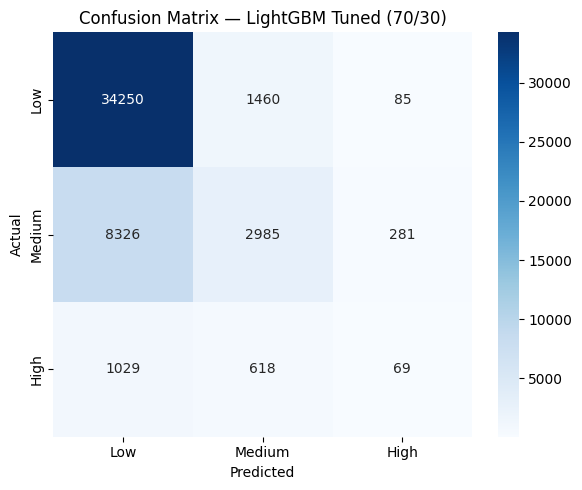

  Confusion matrix saved → cm_LightGBM_Tuned_70_30.png


In [65]:
# Evaluate tuned LightGBM — both splits
res_lgbm_tuned_80 = evaluate_model(lgbm_tuned_80, X_test_80_tree, y_test_80, 'LightGBM Tuned', '80/20')
res_lgbm_tuned_70 = evaluate_model(lgbm_tuned_70, X_test_70_tree, y_test_70, 'LightGBM Tuned', '70/30')
results.append(res_lgbm_tuned_80)
results.append(res_lgbm_tuned_70)

In [66]:
# LightGBM — Baseline vs Tuned Comparison
import pandas as pd
lgbm_comparison = pd.DataFrame([res_lgbm_80, res_lgbm_70, res_lgbm_tuned_80, res_lgbm_tuned_70])
print("LightGBM — Baseline vs Tuned Comparison")
print("=" * 70)
print(lgbm_comparison.to_string(index=False))

LightGBM — Baseline vs Tuned Comparison
         Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
      LightGBM 80/20    0.7512    0.4346       0.7014   0.7262
      LightGBM 70/30    0.7517    0.4323       0.7011   0.7257
LightGBM Tuned 80/20    0.7599    0.4326       0.7155   0.7161
LightGBM Tuned 70/30    0.7597    0.4284       0.7158   0.7133


10. Master Results — All Models Comparison

In [67]:
# All Models — Master Performance Comparison
import pandas as pd

results_df = pd.DataFrame(results)

print("All Models — Master Performance Comparison")
print("=" * 75)
print(results_df.to_string(index=False))

print("\n\nSorted by F1-macro (descending):")
print("=" * 75)
print(results_df.sort_values('F1_macro', ascending=False).to_string(index=False))

All Models — Master Performance Comparison
                    Model Split  Accuracy  F1_macro  F1_weighted  ROC_AUC
            Random Forest 80/20    0.7076    0.4250       0.6917   0.6697
            Random Forest 70/30    0.7043    0.4201       0.6878   0.6682
      Random Forest Tuned 80/20    0.7189    0.4290       0.6997   0.6851
      Random Forest Tuned 70/30    0.7164    0.4245       0.6959   0.6813
                  XGBoost 80/20    0.7560    0.4369       0.7105   0.7185
                  XGBoost 70/30    0.7554    0.4325       0.7102   0.7173
            XGBoost Tuned 80/20    0.7521    0.4310       0.7138   0.6950
            XGBoost Tuned 70/30    0.7496    0.4326       0.7117   0.6879
            XGBoost Tuned 80/20    0.7521    0.4310       0.7138   0.6950
            XGBoost Tuned 70/30    0.7496    0.4326       0.7117   0.6879
      Logistic Regression 80/20    0.5834    0.4048       0.6232   0.6794
      Logistic Regression 70/30    0.5811    0.4041       0.6217   0.

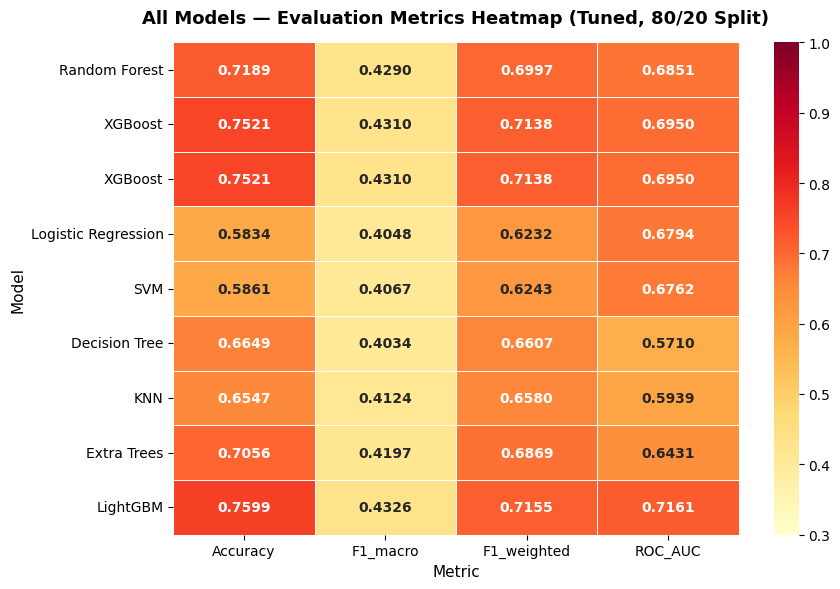

Saved → master_heatmap.png


In [68]:
# Metric Heatmap — tuned models, 80/20 split
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

metrics = ['Accuracy', 'F1_macro', 'F1_weighted', 'ROC_AUC']

tuned_80 = results_df[
    results_df['Model'].str.contains('Tuned') & (results_df['Split'] == '80/20')
].copy()
tuned_80['Model'] = tuned_80['Model'].str.replace(' Tuned', '', regex=False)
heatmap_data = tuned_80.set_index('Model')[metrics]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd',
    vmin=0.30, vmax=1.0, linewidths=0.6,
    annot_kws={'size': 10, 'weight': 'bold'}, ax=ax
)
ax.set_title('All Models — Evaluation Metrics Heatmap (Tuned, 80/20 Split)',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Metric', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
ax.tick_params(axis='x', labelsize=10)
ax.tick_params(axis='y', labelsize=10, rotation=0)
plt.tight_layout()
plt.savefig('master_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_heatmap.png")

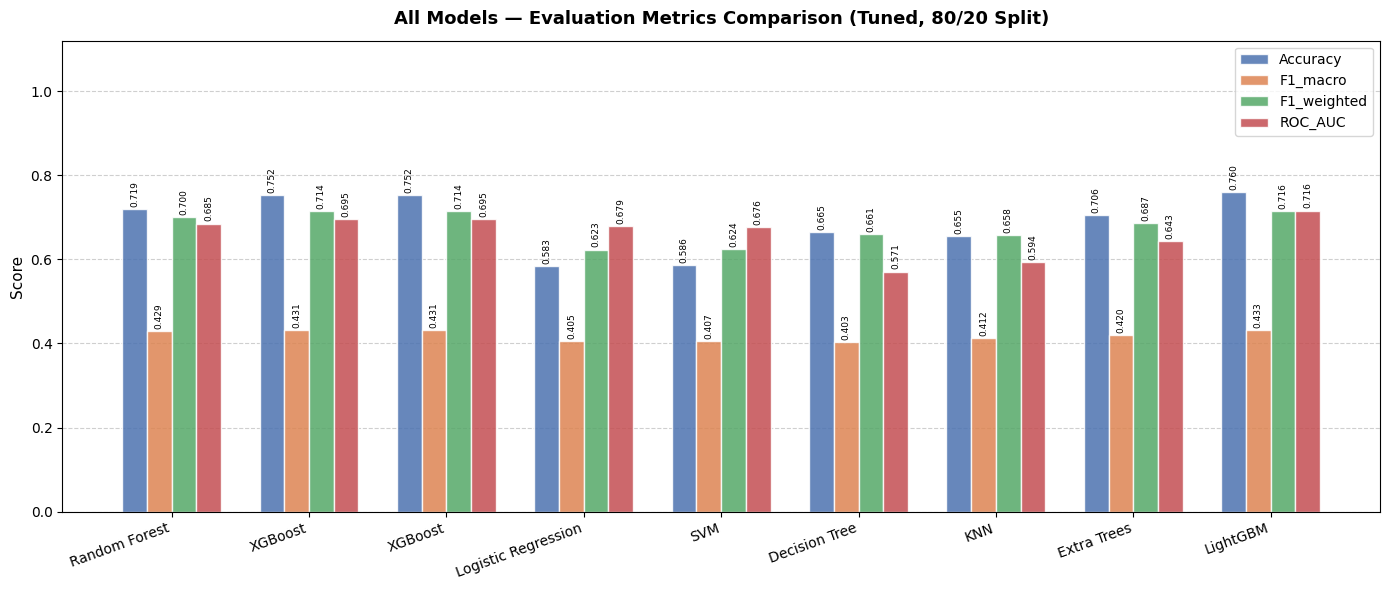

Saved → master_bar_chart.png


In [69]:
# Grouped Bar Chart — all 4 metrics for all tuned models (80/20 split)
import numpy as np
import matplotlib.pyplot as plt

models   = heatmap_data.index.tolist()
metrics  = ['Accuracy', 'F1_macro', 'F1_weighted', 'ROC_AUC']
colors   = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

x      = np.arange(len(models))
width  = 0.18
fig, ax = plt.subplots(figsize=(14, 6))

for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = heatmap_data[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models, rotation=20, ha='right', fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('All Models — Evaluation Metrics Comparison (Tuned, 80/20 Split)',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, loc='upper right')
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('master_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → master_bar_chart.png")

## 11. Save Models for System Deployment

In [70]:
import joblib
import os

# Save top 4 models
joblib.dump(gb_80,       'model_gradient_boosting.pkl')
joblib.dump(xgb_80,      'model_xgboost.pkl')
joblib.dump(lgbm_80,     'model_lightgbm.pkl')
joblib.dump(rf_tuned_80, 'model_random_forest.pkl')

# Save preprocessor — required to transform user input before prediction
joblib.dump(preprocessor_tree, 'preprocessor_tree.pkl')

# Confirm files saved
saved_files = [
    'model_gradient_boosting.pkl',
    'model_xgboost.pkl',
    'model_lightgbm.pkl',
    'model_random_forest.pkl',
    'preprocessor_tree.pkl'
]

print("Models saved successfully:")
for f in saved_files:
    size_kb = os.path.getsize(f) / 1024
    print(f"  {f:<40} ({size_kb:.1f} KB)")

Models saved successfully:
  model_gradient_boosting.pkl              (1400.5 KB)
  model_xgboost.pkl                        (1232.2 KB)
  model_lightgbm.pkl                       (1033.0 KB)
  model_random_forest.pkl                  (727987.9 KB)
  preprocessor_tree.pkl                    (6.0 KB)
